# Air-Quality–Driven Early Warning Health Risk System

# Dataset Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

from xgboost import XGBClassifier
import joblib


C:\Users\91828\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import pandas as pd
aq1 = pd.read_csv("air_quality_2015_2020.csv.csv")
aq1

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [3]:
print(aq1.head())
print(aq1.columns)
print(aq1.shape)

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  
Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')
(29531, 16)


# City Filtering & Date Processing

In [4]:
# Data filtering

# Check unique cities
print(aq1["City"].unique()[:10])
# Filter Delhi data
delhi_aq = aq1[aq1["City"] == "Delhi"].copy()
delhi_aq.head()

['Ahmedabad' 'Aizawl' 'Amaravati' 'Amritsar' 'Bengaluru' 'Bhopal'
 'Brajrajnagar' 'Chandigarh' 'Chennai' 'Coimbatore']


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
10229,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe
10230,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
10231,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate
10232,Delhi,2015-01-04,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,3.34,319.0,Very Poor
10233,Delhi,2015-01-05,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,2.96,325.0,Very Poor


In [5]:

#Date Handling & Sorting
# Convert Date column from text format to datetime
delhi_aq["Date"] = pd.to_datetime(delhi_aq["Date"])
# Sort by date
delhi_aq = delhi_aq.sort_values("Date").reset_index(drop=True)
delhi_aq.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe
1,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
2,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate
3,Delhi,2015-01-04,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,3.34,319.0,Very Poor
4,Delhi,2015-01-05,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,2.96,325.0,Very Poor


# Missing Value Handling (Time-Based Interpolation)

In [6]:
delhi_aq.isna().sum()
# Check missing values

City            0
Date            0
PM2.5           2
PM10           77
NO              2
NO2             2
NOx             0
NH3             9
CO              0
SO2           110
O3             84
Benzene         0
Toluene         0
Xylene        781
AQI            10
AQI_Bucket     10
dtype: int64

In [7]:
#Set Date as index (REQUIRED for time interpolation)
delhi_aq = delhi_aq.set_index("Date")
delhi_aq = delhi_aq.interpolate(method="time").dropna().reset_index()
#Interpolate missing values using TIME method
#Drop any remaining NaNs (edge cases)
delhi_aq.isna().sum()

C:\Users\91828\AppData\Local\Temp\ipykernel_16716\1771056833.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  delhi_aq = delhi_aq.interpolate(method="time").dropna().reset_index()


Date          0
City          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

# Feature Selection

In [8]:
keep_cols = [
    "Date",
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3"
]

delhi_aq = delhi_aq[keep_cols]
delhi_aq

,Date,PM2.5,PM10,NO2,SO2,CO,O3
0,2015-01-01,313.22,607.98,36.39,9.25,15.20,41.68
1,2015-01-02,186.18,269.55,32.87,6.65,9.54,29.97
2,2015-01-03,87.18,131.90,30.31,2.65,10.61,19.71
3,2015-01-04,151.84,241.84,36.91,4.63,11.54,25.36
4,2015-01-05,146.60,219.13,34.92,3.33,9.20,23.20
...,...,...,...,...,...,...,...
1994,2020-06-27,39.80,155.94,21.46,10.38,0.87,18.88
1995,2020-06-28,59.52,308.65,21.60,10.70,0.94,18.05
1996,2020-06-29,44.86,184.12,21.57,11.58,0.88,26.61
1997,2020-06-30,39.80,91.98,17.96,10.51,0.84,37.29


In [9]:
delhi_aq.isna().sum()

Date     0
PM2.5    0
PM10     0
NO2      0
SO2      0
CO       0
O3       0
dtype: int64

# Feature Engineering (Lag + Rolling Exposure)


In [10]:
# Create lag features for PM2.5 and PM10
LAGS = [1, 3, 7]

for lag in LAGS:
    delhi_aq[f"PM2.5_lag_{lag}"] = delhi_aq["PM2.5"].shift(lag)
    delhi_aq[f"PM10_lag_{lag}"] = delhi_aq["PM10"].shift(lag)


In [11]:
delhi_aq.head(10)


,Date,PM2.5,PM10,NO2,SO2,CO,O3,PM2.5_lag_1,PM10_lag_1,PM2.5_lag_3,PM10_lag_3,PM2.5_lag_7,PM10_lag_7
0,2015-01-01,313.22,607.98,36.39,9.25,15.20,41.68,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-02,186.18,269.55,32.87,6.65,9.54,29.97,313.22,607.98,NaN,NaN,NaN,NaN
2,2015-01-03,87.18,131.90,30.31,2.65,10.61,19.71,186.18,269.55,NaN,NaN,NaN,NaN
3,2015-01-04,151.84,241.84,36.91,4.63,11.54,25.36,87.18,131.90,313.22,607.98,NaN,NaN
4,2015-01-05,146.60,219.13,34.92,3.33,9.20,23.20,151.84,241.84,186.18,269.55,NaN,NaN
5,2015-01-06,149.58,252.10,37.84,3.66,9.44,26.83,146.60,219.13,87.18,131.90,NaN,NaN
6,2015-01-07,217.87,376.51,40.15,5.82,9.78,28.96,149.58,252.10,151.84,241.84,NaN,NaN
7,2015-01-08,229.90,360.95,43.16,3.31,11.01,30.51,217.87,376.51,146.60,219.13,313.22,607.98
8,2015-01-09,201.66,397.43,38.56,3.48,11.09,32.94,229.90,360.95,149.58,252.10,186.18,269.55
9,2015-01-10,221.02,361.74,46.39,5.91,9.70,34.12,201.66,397.43,217.87,376.51,87.18,131.90


In [12]:
#Rolling Averages

# Rolling exposure features for PM2.5
delhi_aq["PM2.5_3day_avg"] = delhi_aq["PM2.5"].rolling(window=3).mean()
delhi_aq["PM2.5_7day_avg"] = delhi_aq["PM2.5"].rolling(window=7).mean()

# Rolling exposure features for PM10
delhi_aq["PM10_3day_avg"] = delhi_aq["PM10"].rolling(window=3).mean()
delhi_aq["PM10_7day_avg"] = delhi_aq["PM10"].rolling(window=7).mean()


In [13]:
delhi_aq.head(10)


,Date,PM2.5,PM10,NO2,SO2,CO,O3,PM2.5_lag_1,PM10_lag_1,PM2.5_lag_3,PM10_lag_3,PM2.5_lag_7,PM10_lag_7,PM2.5_3day_avg,PM2.5_7day_avg,PM10_3day_avg,PM10_7day_avg
0,2015-01-01,313.22,607.98,36.39,9.25,15.20,41.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-02,186.18,269.55,32.87,6.65,9.54,29.97,313.22,607.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-03,87.18,131.90,30.31,2.65,10.61,19.71,186.18,269.55,NaN,NaN,NaN,NaN,195.526667,NaN,336.476667,NaN
3,2015-01-04,151.84,241.84,36.91,4.63,11.54,25.36,87.18,131.90,313.22,607.98,NaN,NaN,141.733333,NaN,214.430000,NaN
4,2015-01-05,146.60,219.13,34.92,3.33,9.20,23.20,151.84,241.84,186.18,269.55,NaN,NaN,128.540000,NaN,197.623333,NaN
5,2015-01-06,149.58,252.10,37.84,3.66,9.44,26.83,146.60,219.13,87.18,131.90,NaN,NaN,149.340000,NaN,237.690000,NaN
6,2015-01-07,217.87,376.51,40.15,5.82,9.78,28.96,149.58,252.10,151.84,241.84,NaN,NaN,171.350000,178.924286,282.580000,299.858571
7,2015-01-08,229.90,360.95,43.16,3.31,11.01,30.51,217.87,376.51,146.60,219.13,313.22,607.98,199.116667,167.021429,329.853333,264.568571
8,2015-01-09,201.66,397.43,38.56,3.48,11.09,32.94,229.90,360.95,149.58,252.10,186.18,269.55,216.476667,169.232857,378.296667,282.837143
9,2015-01-10,221.02,361.74,46.39,5.91,9.70,34.12,201.66,397.43,217.87,376.51,87.18,131.90,217.526667,188.352857,373.373333,315.671429


# Target Variable Creation (Health Risk Label)

In [14]:
def create_risk_label(row):
    if row["PM2.5_3day_avg"] > 35:
        return 1   # High-risk day
    else:
        return 0   # Normal day

delhi_aq["high_risk"] = delhi_aq.apply(create_risk_label, axis=1)
delhi_aq["high_risk"].value_counts()

high_risk
1    1872
0     127
Name: count, dtype: int64


# Data Cleaning Before Modeling

In [15]:
delhi_aq[["Date", "PM2.5", "PM2.5_3day_avg", "high_risk"]].head(10)


,Date,PM2.5,PM2.5_3day_avg,high_risk
0,2015-01-01,313.22,NaN,0
1,2015-01-02,186.18,NaN,0
2,2015-01-03,87.18,195.526667,1
3,2015-01-04,151.84,141.733333,1
4,2015-01-05,146.60,128.540000,1
5,2015-01-06,149.58,149.340000,1
6,2015-01-07,217.87,171.350000,1
7,2015-01-08,229.90,199.116667,1
8,2015-01-09,201.66,216.476667,1
9,2015-01-10,221.02,217.526667,1


In [16]:
delhi_aq = delhi_aq.dropna().reset_index(drop=True)


In [17]:
delhi_aq["high_risk"].value_counts()


high_risk
1    1867
0     125
Name: count, dtype: int64

In [18]:
delhi_aq = delhi_aq.sort_values("Date").reset_index(drop=True)


# Train–Test Split (Time-Aware)

In [19]:
X = delhi_aq.drop(
    columns=["Date", "high_risk", "PM2.5_3day_avg"]
)
y = delhi_aq["high_risk"]


In [20]:
split_index = int(0.8 * len(delhi_aq))

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]


# Model Traning

# LOGISTIC REGRESSION

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:

log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))



Logistic Regression
[[ 54   1]
 [ 51 293]]
              precision    recall  f1-score   support

           0       0.51      0.98      0.67        55
           1       1.00      0.85      0.92       344

    accuracy                           0.87       399
   macro avg       0.76      0.92      0.80       399
weighted avg       0.93      0.87      0.88       399



# RandomForest

In [23]:


rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest
[[ 36  19]
 [  3 341]]
              precision    recall  f1-score   support

           0       0.92      0.65      0.77        55
           1       0.95      0.99      0.97       344

    accuracy                           0.94       399
   macro avg       0.94      0.82      0.87       399
weighted avg       0.94      0.94      0.94       399



# XGBoost

In [24]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight = neg / pos,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Results")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBoost Results
[[ 52   3]
 [ 19 325]]
              precision    recall  f1-score   support

           0       0.73      0.95      0.83        55
           1       0.99      0.94      0.97       344

    accuracy                           0.94       399
   macro avg       0.86      0.95      0.90       399
weighted avg       0.96      0.94      0.95       399



# Model Evaluation

In [25]:


def model_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)
    false_negatives = cm[1][0]

    return acc, rec, prec, f1, false_negatives


In [26]:
results = []

results.append(("Logistic Regression", *model_metrics(y_test, y_pred_lr)))
results.append(("Random Forest", *model_metrics(y_test, y_pred_rf)))
results.append(("XGBoost", *model_metrics(y_test, y_pred_xgb)))

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Recall (High-Risk)",
        "Precision (High-Risk)",
        "F1 (High-Risk)",
        "False Negatives"
    ]
)

comparison_df


,Model,Accuracy,Recall (High-Risk),Precision (High-Risk),F1 (High-Risk),False Negatives
0,Logistic Regression,0.869674,0.851744,0.996599,0.918495,51
1,Random Forest,0.944862,0.991279,0.947222,0.968750,3
2,XGBoost,0.944862,0.944767,0.990854,0.967262,19


# PLOTS

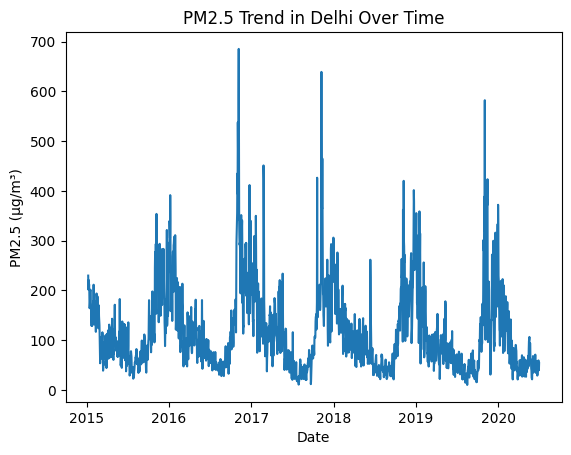

In [27]:
#Plot 1: PM2.5 Trend Over Time
     
import matplotlib.pyplot as plt

plt.figure()
plt.plot(delhi_aq["Date"], delhi_aq["PM2.5"])
plt.title("PM2.5 Trend in Delhi Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()


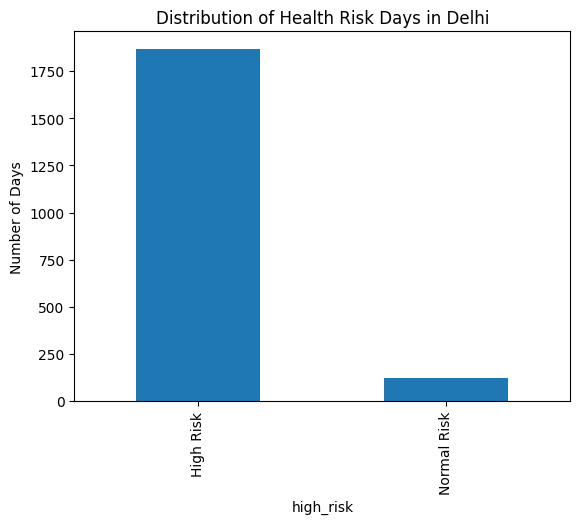

In [28]:
# Plot 2: High vs Normal Risk Distribution
delhi_aq["high_risk"].value_counts().rename(
    {0: "Normal Risk", 1: "High Risk"}
).plot(kind="bar")

plt.title("Distribution of Health Risk Days in Delhi")
plt.ylabel("Number of Days")
plt.show()


# Model Saving

In [29]:
joblib.dump(rf, "model/random_forest.pkl")

['model/random_forest.pkl']

In [30]:
feature_columns = X_train.columns.tolist()
feature_columns


['PM2.5',
 'PM10',
 'NO2',
 'SO2',
 'CO',
 'O3',
 'PM2.5_lag_1',
 'PM10_lag_1',
 'PM2.5_lag_3',
 'PM10_lag_3',
 'PM2.5_lag_7',
 'PM10_lag_7',
 'PM2.5_7day_avg',
 'PM10_3day_avg',
 'PM10_7day_avg']

In [31]:

joblib.dump(X_train.columns.tolist(), "model/feature_columns.pkl")


['model/feature_columns.pkl']

In [32]:
joblib.dump(feature_columns, "model/feature_columns.pkl")


['model/feature_columns.pkl']

# Deployment & User Interface

In [33]:
import gradio as gr
import joblib
import numpy as np
import pandas as pd

# ---------------- Load trained objects ----------------
model = joblib.load("model/random_forest.pkl")
feature_columns = joblib.load("model/feature_columns.pkl")

# ---------------- Prediction function ----------------
def predict_health_risk(pm25, pm10, no2, so2, co, o3):

    # Prepare input dictionary
    input_dict = {
        "PM2.5": pm25,
        "PM10": pm10,
        "NO2": no2,
        "SO2": so2,
        "CO": co,
        "O3": o3,
    }

    # Add missing training features (lag/rolling) as 0 for demo
    for col in feature_columns:
        if col not in input_dict:
            input_dict[col] = 0

    # Convert to dataframe in correct order
    input_df = pd.DataFrame([input_dict])
    input_df = input_df[feature_columns]

    # Predict
    proba = model.predict_proba(input_df)
    pred = model.predict(input_df)

    prediction = pred[0]
    confidence = np.max(proba) * 100

    # Output message (same style as yours)
    if prediction == 1:
        return (
            "🔴 EARLY WARNING: HIGH HEALTH RISK\n\n"
            "City: Delhi\n"
            f"Confidence Score: {confidence:.1f}%\n\n"
            "Meaning:\n"
            "- Air pollution levels exceed safe limits.\n"
            "- Increased health risk, especially for sensitive groups.\n\n"
            "Health Advisory:\n"
            "- Avoid prolonged outdoor activities.\n"
            "- Children, elderly, and asthma patients should take precautions.\n"
            "- Use protective masks if necessary."
        )
    else:
        return (
            "🟢 EARLY WARNING: LOW/NORMAL HEALTH RISK\n\n"
            "City: Delhi\n"
            f"Confidence Score: {confidence:.1f}%\n\n"
            "Meaning:\n"
            "- Air quality is within acceptable limits.\n"
            "- Minimal immediate health impact.\n\n"
            "Health Advisory:\n"
            "- Outdoor activities are generally safe.\n"
            "- Maintain routine health precautions."
        )

# ---------------- Interface ----------------
iface = gr.Interface(
    fn=predict_health_risk,
    inputs=[
        gr.Number(label="PM2.5 (µg/m³)"),
        gr.Number(label="PM10 (µg/m³)"),
        gr.Number(label="NO2 (µg/m³)"),
        gr.Number(label="SO2 (µg/m³)"),
        gr.Number(label="CO (mg/m³)"),
        gr.Number(label="O3 (µg/m³)")
    ],
    outputs=gr.Textbox(label="Early Warning Output"),
    title="Air-Quality–Driven Early Warning Health Risk System",
    description=(
        "Early warning system for predicting population health risk using air quality "
        "indicators. The current model is trained and validated using Delhi air quality data."
    )
)

# ---------------- Notes / Explanation ----------------
note = gr.Markdown("""
### 📌 Important Note
- The current version of this system is trained and evaluated using **Delhi air quality data**.
- Predictions reflect **city-specific pollution–health risk patterns** learned from Delhi.
- The system is designed to be extended to other cities through retraining and calibration.
""")

# ---------------- App layout ----------------
with gr.Blocks() as demo:
    iface.render()
    note.render()

# ---------------- Launch ----------------
demo.launch(share=True)


* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
